In [3]:
import pandas_datareader as pdr
import pandas as pd
from datetime import datetime

In [4]:
df=pd.read_csv('/content/features (1).csv')
df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [5]:
df=df.drop(['MarkDown1','MarkDown2','MarkDown3','MarkDown4'],axis=1)

In [6]:
df=df.drop(['MarkDown5'],axis=1)

In [7]:
df=df.drop(['IsHoliday'],axis=1)

In [8]:
df.head()

,Store,Date,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,42.31,2.572,211.096358,8.106
1,1,2010-02-12,38.51,2.548,211.242170,8.106
2,1,2010-02-19,39.93,2.514,211.289143,8.106
3,1,2010-02-26,46.63,2.561,211.319643,8.106
4,1,2010-03-05,46.50,2.625,211.350143,8.106


In [9]:
df.tail()

,Store,Date,Temperature,Fuel_Price,CPI,Unemployment
8185,45,2013-06-28,76.05,3.639,NaN,NaN
8186,45,2013-07-05,77.50,3.614,NaN,NaN
8187,45,2013-07-12,79.37,3.614,NaN,NaN
8188,45,2013-07-19,82.84,3.737,NaN,NaN
8189,45,2013-07-26,76.06,3.804,NaN,NaN


In [10]:
df.shape

(8190, 6)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   CPI           7605 non-null   float64
 5   Unemployment  7605 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 384.0+ KB


In [12]:
df.describe()

,Store,Temperature,Fuel_Price,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,172.460809,7.826821
std,12.987966,18.678607,0.431337,39.738346,1.877259
min,1.000000,-7.290000,2.472000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,132.364839,6.634000
50%,23.000000,60.710000,3.513000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,213.932412,8.567000
max,45.000000,101.950000,4.468000,228.976456,14.313000


<Axes: >

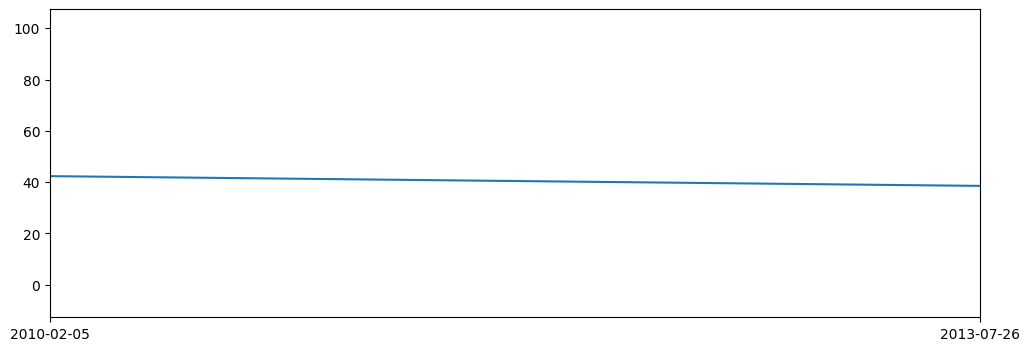

In [13]:
df['Temperature'].plot(xlim=['2010-02-05','2013-07-26'],figsize=(12,4))

<Axes: >

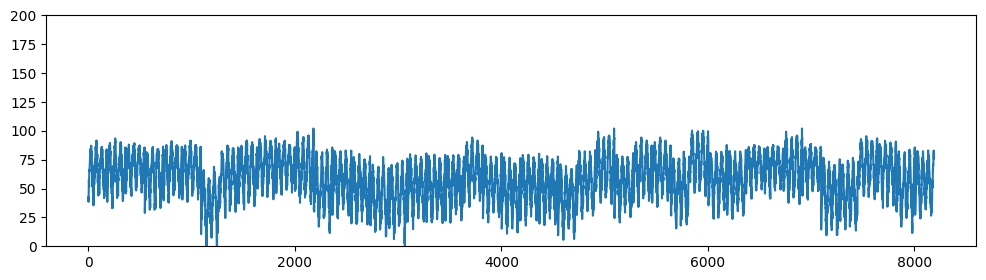

In [14]:
## xlimit and y limit
df['Temperature'].plot(ylim=[0,200],figsize=(12,3))

In [15]:
index=df.loc['2010-02-05':'2013-07-26'].index
temp=df.loc['2010-02-05':'2013-07-26']['Temperature']

<Axes: >

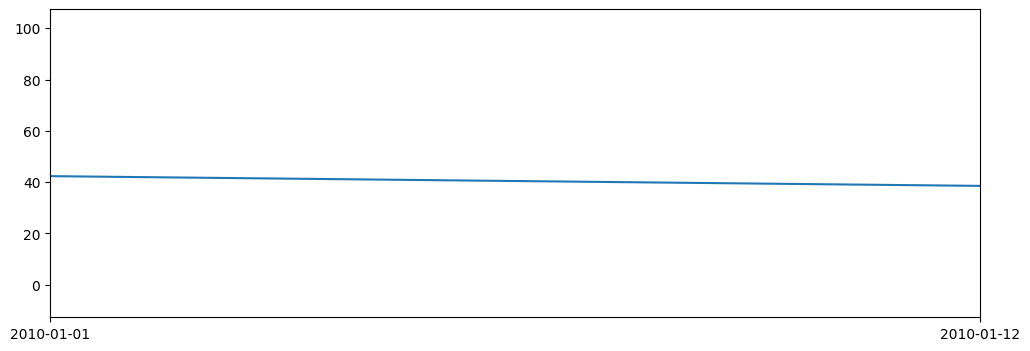

In [16]:
## xlimit and y limit
df['Temperature'].plot(xlim=['2010-01-01','2010-01-12'],figsize=(12,4))

In [17]:
df=df.reset_index()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         8190 non-null   int64  
 1   Store         8190 non-null   int64  
 2   Date          8190 non-null   object 
 3   Temperature   8190 non-null   float64
 4   Fuel_Price    8190 non-null   float64
 5   CPI           7605 non-null   float64
 6   Unemployment  7605 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 448.0+ KB


In [19]:
df=df.set_index('Date',drop=True)

In [20]:
  df

,index,Store,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,
2010-02-05,0,1,42.31,2.572,211.096358,8.106
2010-02-12,1,1,38.51,2.548,211.242170,8.106
2010-02-19,2,1,39.93,2.514,211.289143,8.106
2010-02-26,3,1,46.63,2.561,211.319643,8.106
2010-03-05,4,1,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...
2013-06-28,8185,45,76.05,3.639,NaN,NaN
2013-07-05,8186,45,77.50,3.614,NaN,NaN
2013-07-12,8187,45,79.37,3.614,NaN,NaN


In [21]:
## datetime
from datetime import datetime

In [22]:
df.index = pd.to_datetime(df.index)
df.resample(rule='A').min()

/tmp/ipykernel_619/2552148319.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').min()


,index,Store,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,
2010-12-31,0,1,9.55,2.472,126.064000,5.287
2011-12-31,48,1,-2.06,2.882,127.191774,4.420
2012-12-31,100,1,2.32,3.031,130.157516,3.879
2013-12-31,152,1,-7.29,2.872,131.852000,3.684


In [23]:
df.resample(rule='A').max()

/tmp/ipykernel_619/1351435405.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max()


,index,Store,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,
2010-12-31,8055,45,100.14,3.336,215.555730,14.313
2011-12-31,8107,45,99.66,4.211,223.249677,14.021
2012-12-31,8159,45,100.07,4.468,227.761063,12.187
2013-12-31,8189,45,101.95,4.125,228.976456,9.910


/tmp/ipykernel_619/3561300434.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max()['Temperature'].plot()


<Axes: xlabel='Date'>

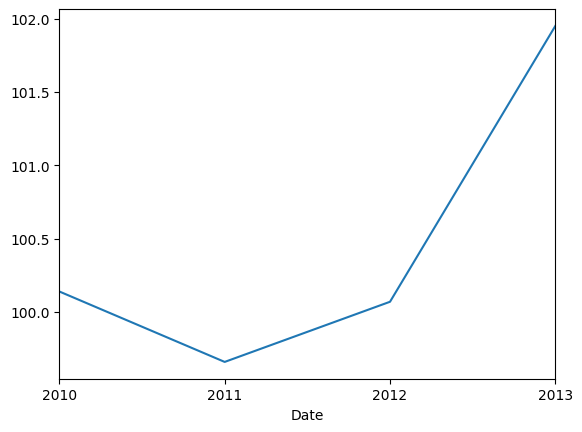

In [24]:
##year end frequency
df.resample(rule='A').max()['Temperature'].plot()

<Axes: xlabel='Date'>

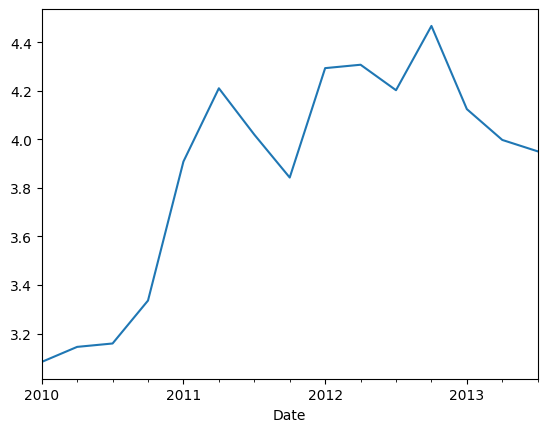

In [25]:
df.resample(rule='QS').max()['Fuel_Price'].plot()

In [26]:
df.resample(rule='BA').max()

/tmp/ipykernel_619/2586250062.py:1: FutureWarning: 'BA' is deprecated and will be removed in a future version, please use 'BYE' instead.
  df.resample(rule='BA').max()


,index,Store,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,
2010-12-31,8055,45,100.14,3.336,215.555730,14.313
2011-12-30,8107,45,99.66,4.211,223.249677,14.021
2012-12-31,8159,45,100.07,4.468,227.761063,12.187
2013-12-31,8189,45,101.95,4.125,228.976456,9.910


In [27]:
df.resample(rule='BQS').max()

,index,Store,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,
2010-01-01,8015,45,64.60,3.083,214.932899,13.975
2010-04-01,8028,45,93.66,3.145,215.018719,14.099
2010-07-01,8041,45,100.14,3.159,215.203976,14.180
2010-10-01,8055,45,91.45,3.336,215.555730,14.313
2011-01-03,8067,45,73.74,3.909,218.200751,14.021
2011-04-01,8080,45,94.11,4.211,219.604183,13.736
2011-07-01,8094,45,99.66,4.020,220.319500,13.503
2011-10-03,8107,45,81.74,3.843,223.249677,12.890
2012-01-02,8120,45,72.63,4.294,225.107867,12.187


/tmp/ipykernel_619/264745897.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df['Temperature'].resample(rule='A').mean().plot(kind='bar')


<Axes: xlabel='Date'>

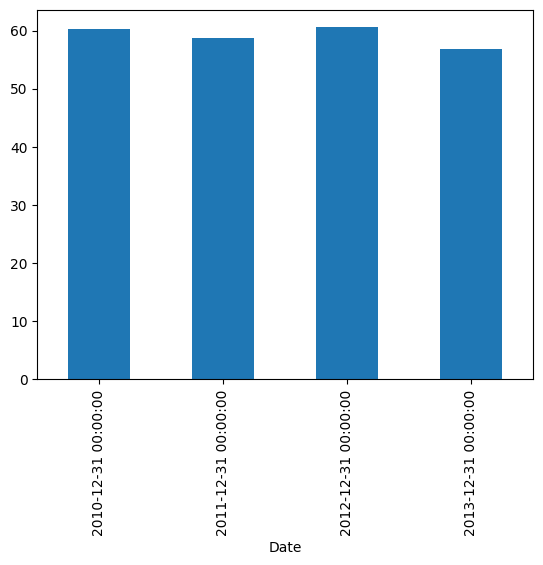

In [28]:
##plotting
df['Temperature'].resample(rule='A').mean().plot(kind='bar')

/tmp/ipykernel_619/301417915.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df['Fuel_Price'].resample(rule='A').mean().plot(kind='bar')


<Axes: xlabel='Date'>

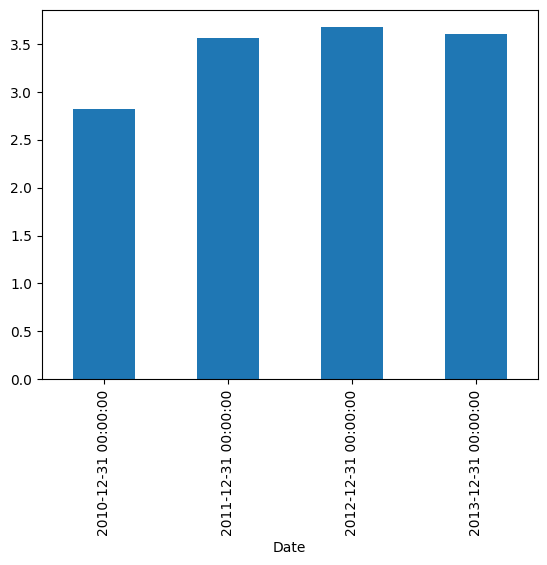

In [29]:
df['Fuel_Price'].resample(rule='A').mean().plot(kind='bar')

/tmp/ipykernel_619/2889645759.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['Temperature'].resample(rule='M').max().plot(kind='bar',figsize=(15,6))


<Axes: xlabel='Date'>

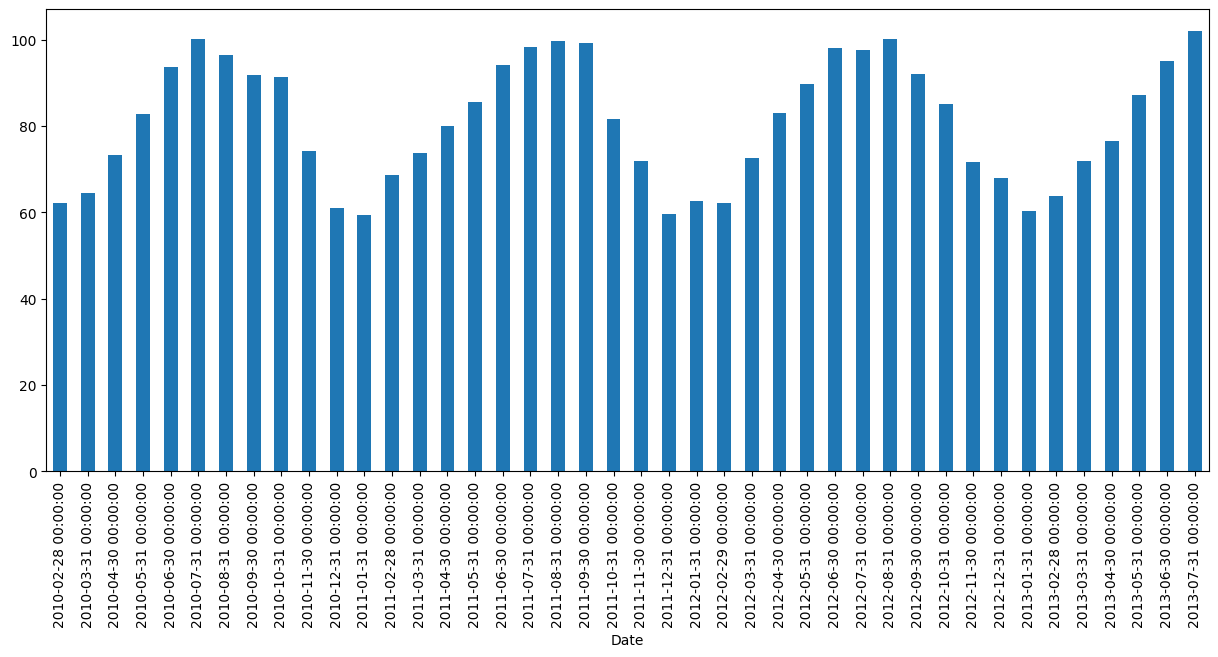

In [30]:
df['Temperature'].resample(rule='M').max().plot(kind='bar',figsize=(15,6))

In [31]:
A=df['Temperature'].rolling(3).mean()

In [32]:
A

,Temperature
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,40.250000
2010-02-26,41.690000
2010-03-05,44.353333
...,...
2013-06-28,72.063333
2013-07-05,74.560000
2013-07-12,77.640000


In [33]:
df.head()

,index,Store,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,
2010-02-05,0,1,42.31,2.572,211.096358,8.106
2010-02-12,1,1,38.51,2.548,211.242170,8.106
2010-02-19,2,1,39.93,2.514,211.289143,8.106
2010-02-26,3,1,46.63,2.561,211.319643,8.106
2010-03-05,4,1,46.50,2.625,211.350143,8.106


In [34]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [36]:
test_result=adfuller(df['Temperature'])

In [37]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(Temperature):
    result=adfuller(Temperature)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [38]:
adfuller_test(df['Temperature'])

ADF Test Statistic : -8.331707019312585
p-value : 3.3548568621185855e-13
#Lags Used : 37
Number of Observations Used : 8152
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


In [39]:
df['Temerature first difference'] = df['Temperature'] - df['Temperature'].shift(1)

In [40]:
df['Temperature'].shift(1)

,Temperature
Date,
2010-02-05,NaN
2010-02-12,42.31
2010-02-19,38.51
2010-02-26,39.93
2010-03-05,46.63
...,...
2013-06-28,70.13
2013-07-05,76.05
2013-07-12,77.50


In [41]:
df['Seasonal First Difference']=df['Temperature']-df['Temperature'].shift(12)

In [42]:
df.head(14)

,index,Store,Temperature,Fuel_Price,CPI,Unemployment,Temerature first difference,Seasonal First Difference
Date,,,,,,,,
2010-02-05,0,1,42.31,2.572,211.096358,8.106,NaN,NaN
2010-02-12,1,1,38.51,2.548,211.242170,8.106,-3.80,NaN
2010-02-19,2,1,39.93,2.514,211.289143,8.106,1.42,NaN
2010-02-26,3,1,46.63,2.561,211.319643,8.106,6.70,NaN
2010-03-05,4,1,46.50,2.625,211.350143,8.106,-0.13,NaN
2010-03-12,5,1,57.79,2.667,211.380643,8.106,11.29,NaN
2010-03-19,6,1,54.58,2.720,211.215635,8.106,-3.21,NaN
2010-03-26,7,1,51.45,2.732,211.018042,8.106,-3.13,NaN
2010-04-02,8,1,62.27,2.719,210.820450,7.808,10.82,NaN


In [43]:
## Again test dickey fuller test
adfuller_test(df['Seasonal First Difference'].dropna())

ADF Test Statistic : -21.660210738658865
p-value : 0.0
#Lags Used : 37
Number of Observations Used : 8140
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<Axes: xlabel='Date'>

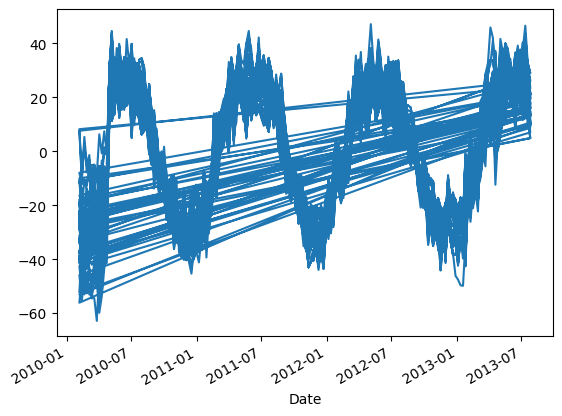

In [44]:
df['Seasonal First Difference'].plot()

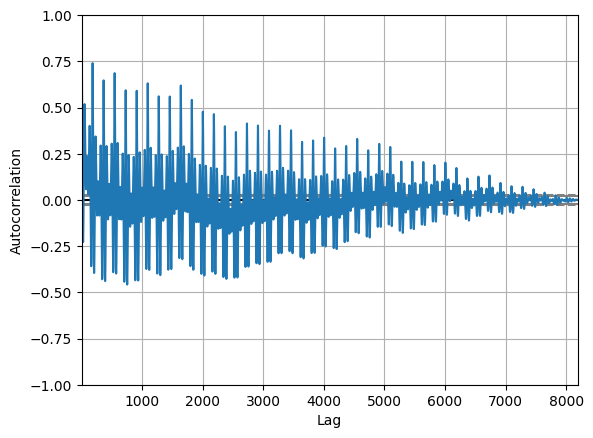

In [46]:
import matplotlib.pyplot as plt

from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df['Temperature'])
plt.show()

In [47]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

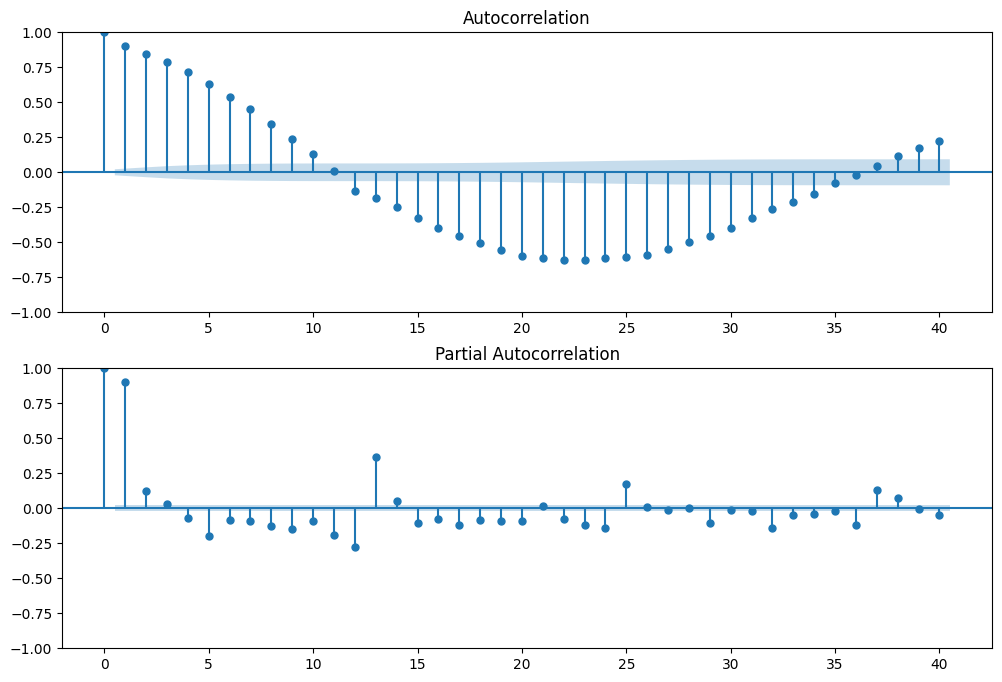

In [48]:
import statsmodels.api as sm
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Seasonal First Difference'].iloc[13:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Seasonal First Difference'].iloc[13:],lags=40,ax=ax2)